In [80]:
import numpy as np
population = np.random.rand(10,1000,5000)
print('population mean is : ',np.mean(population))

population mean is :  0.4999239518626739


In [81]:
population[0][0].ndim

1

In [82]:
# samples
sample_1 = np.random.choice(population[0][0],50)
sample_2 = np.random.choice(population[0][0],50)
sample_3 = np.random.choice(population[0][0],50)
print(np.mean(sample_1))
print(np.mean(sample_2))
print(np.mean(sample_3))

(np.mean(sample_1) + np.mean(sample_2) + np.mean(sample_3))/3

0.5754496233515586
0.4811202001327784
0.5101331128872768


np.float64(0.5222343121238713)

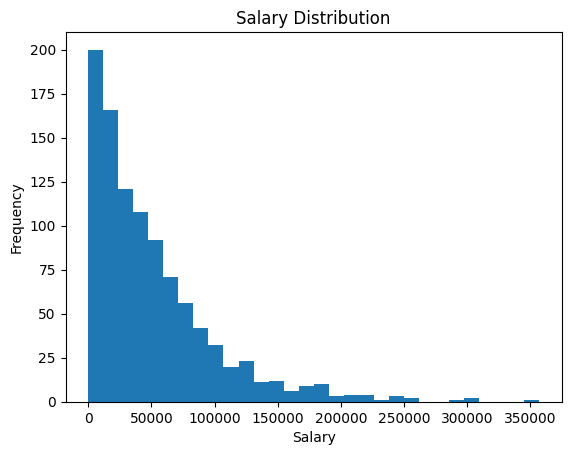

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# salary as a columns  : salary will look skewed data
salary = np.random.exponential(scale=50000, size=1000)
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

In [84]:
# salary mean
print('Salary Mean : ', np.mean(salary))

Salary Mean :  50622.306469447285


In [85]:
# samples from salary data
s1 = np.random.choice(salary, 50)
s2 = np.random.choice(salary, 50)
s3 = np.random.choice(salary, 50)

# compute the samples mean
avg_sample_mean = (np.mean(s1) + np.mean(s2) + np.mean(s3))/3
print('Average of Sample Means : ', avg_sample_mean)

Average of Sample Means :  50288.202820391096


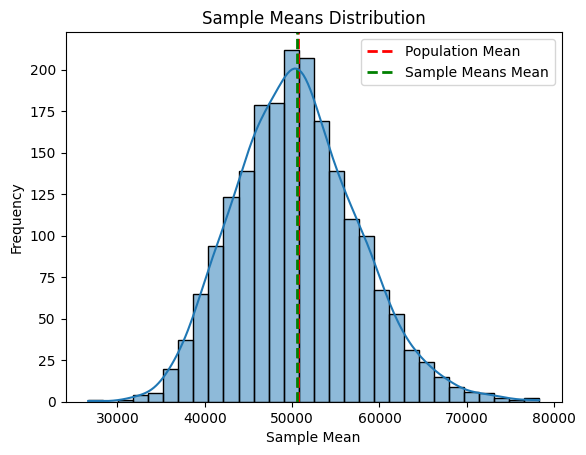

In [86]:
# lets plot the sample means distribution
sample_means = []
for _ in range(2000):
    sample = np.random.choice(salary, 50)
    sample_means.append(np.mean(sample))

# lets plot sample mean and population mean
plt.axvline(np.mean(salary), color='r', linestyle='dashed', linewidth=2, label='Population Mean')
plt.axvline(np.mean(sample_means), color='g', linestyle='dashed', linewidth=2, label='Sample Means Mean')
sns.histplot(sample_means, bins=30, kde=True)
plt.title('Sample Means Distribution')
plt.xlabel('Sample Mean')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [87]:
# Basically in CLT, we are saying that
# No matter what the population distribution is,
#  the distribution of the sample means will be approximately normal
#  if the sample size is sufficiently large (usually n > 30).

# This is a powerful concept because it allows us to make inferences about population parameters
#  using the properties of the normal distribution, even when the population itself is not normally distributed

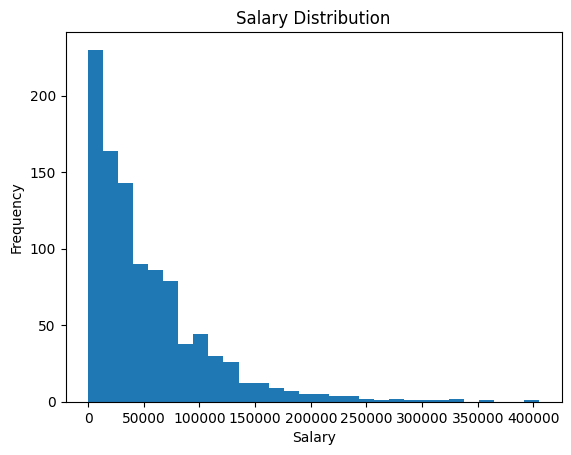

In [88]:
salary = np.random.exponential(scale=50000, size=1000)
plt.hist(salary, bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

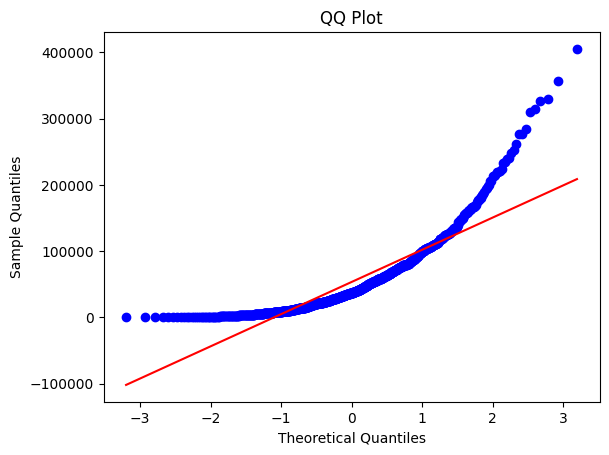

In [89]:
# QQ plot
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(salary, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

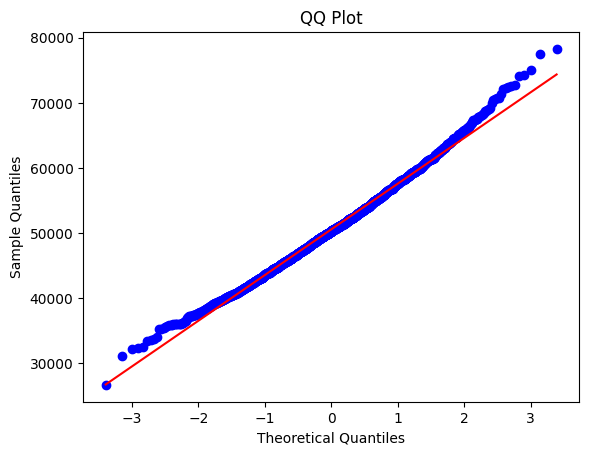

In [90]:
stats.probplot(sample_means, dist="norm", plot=plt)
plt.title('QQ Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()

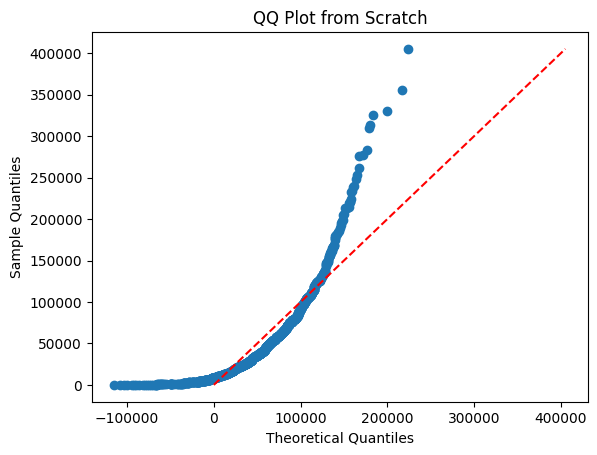

In [91]:
# Assignment  1 : Implement QQ plot from scratch
# Assignemnt  2 : Change mean to median in CLT example and observe the changes
import numpy as np
import matplotlib.pyplot as plt

# first sort the data
sorted_data = np.sort(salary)

# percentiles
n = len(sorted_data)
percentiles = (np.arange(1, n + 1) - 0.5) / n

# lets take normal distribution 
y = np.random.normal(loc=np.mean(salary), scale=np.std(salary), size=n)
y_sorted = np.sort(y)
# calculate the theoretical quantiles
theoretical_quantiles = np.percentile(y_sorted, percentiles * 100)
# 45 degree line
max_val = max(max(theoretical_quantiles), max(sorted_data))
plt.plot([0, max_val], [0, max_val], color='r', linestyle='--', label='45 Degree Line')
# plot the QQ plot
plt.scatter(theoretical_quantiles, sorted_data)
plt.title('QQ Plot from Scratch')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Sample Quantiles')
plt.show()  

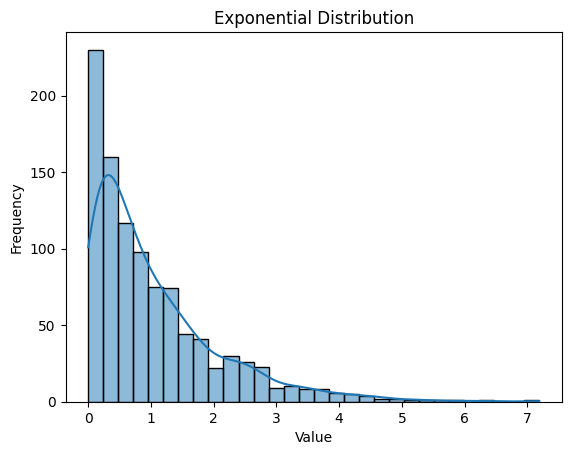

In [92]:
# lets generate exponential data 
data = np.random.exponential(scale=1.0, size=1000)
sns.histplot(data, bins=30, kde=True)
plt.title('Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

Fitted Lambda :  0.24807021265578152


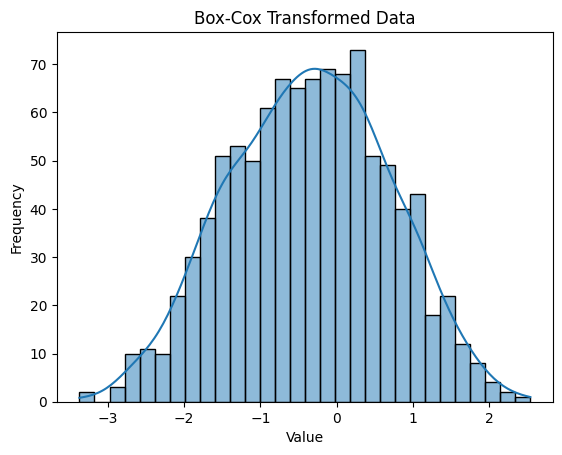

In [93]:
# Pareto Distribution --> Normal distribution
from scipy.stats import boxcox
boxcox_data, fitted_lambda = boxcox(data)
print('Fitted Lambda : ', fitted_lambda)
sns.histplot(boxcox_data, bins=30, kde=True)
plt.title('Box-Cox Transformed Data')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

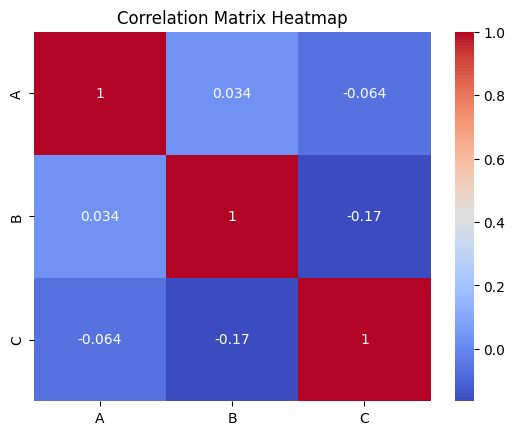

In [94]:
# lets create random pandas data to show corr
import pandas as pd
df = pd.DataFrame({
    'A': np.random.rand(100),
    'B': np.random.rand(100),
    'C': np.random.rand(100)
})
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()


In [95]:
# Assignment 1:
# Compute covariance from scratch
# create dummy data and then compute covariance matrix

In [96]:
# Compute covariance from scratch
import numpy as np
data = np.array([[2.5, 2.4],
                 [0.5, 0.7],
                 [2.2, 2.9],
                 [1.9, 2.2],
                 [3.1, 3.0],
                 [2.3, 2.7],
                 [2, 1.6],
                 [1, 1.1],
                 [1.5, 1.6],
                 [1.1, 0.9]])
# Step 1: Calculate the mean of each column
mean = np.mean(data, axis=0)
print('Mean:\n', mean)

# Step 2: Center the data by subtracting the mean
centered_data = data - mean
print('Centered Data:\n', centered_data)

# Step 3: Calculate the covariance matrix
print('Data Shape:', data.shape)

cov_matrix = np.dot(centered_data.T, centered_data) / (data.shape[0] - 1)
print('Covariance Matrix from Scratch:\n', cov_matrix)

Mean:
 [1.81 1.91]
Centered Data:
 [[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]
Data Shape: (10, 2)
Covariance Matrix from Scratch:
 [[0.61655556 0.61544444]
 [0.61544444 0.71655556]]


Covariance Matrix from Scratch:
 [[ 0.08863946  0.00943641  0.00189377]
 [ 0.00943641  0.08292275 -0.00637542]
 [ 0.00189377 -0.00637542  0.09183741]]


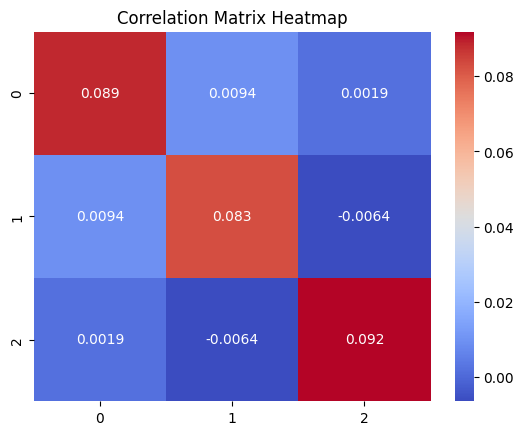

In [97]:
# Compute covariance from scratch with the given data(population formula)

import numpy as np
import pandas as pd

def compute_covariance_matrix(data):
   data = pd.DataFrame(data)
      
   # Step 1: Calculate the mean of each column
   mean = data.mean()
   # print('Mean:\n', data.mean())


   # Step 2: Center the data by subtracting the mean
   centered_data = data - mean
   # print('Centered Data:\n', centered_data)

   # Step 3: Calculate the covariance matrix
   cov_matrix = np.dot(centered_data.T, centered_data) / (data.shape[0])
   print('Covariance Matrix from Scratch:\n', cov_matrix)
   return cov_matrix, data

data = {
   'A': np.random.rand(100),
   'B': np.random.rand(100),
   'C': np.random.rand(100)
}

# print(pd.DataFrame(data))
covariance_matrix, data = compute_covariance_matrix(data)
sns.heatmap(covariance_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

Covariance Matrix from Scratch:
 [[ 0.05490152 -0.01744469 -0.01821029]
 [-0.01744469  0.05643111 -0.01174902]
 [-0.01821029 -0.01174902  0.07262066]]
Pearson Correlation Coefficient Matrix:
 [[ 3.12511899 -0.99299128 -1.03657078]
 [-0.99299128  3.2121868  -0.66878092]
 [-1.03657078 -0.66878092  4.13373274]]


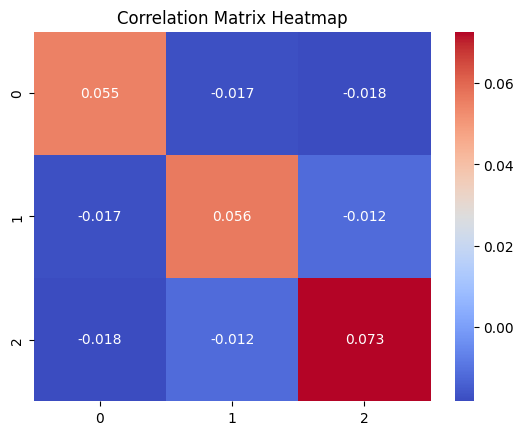

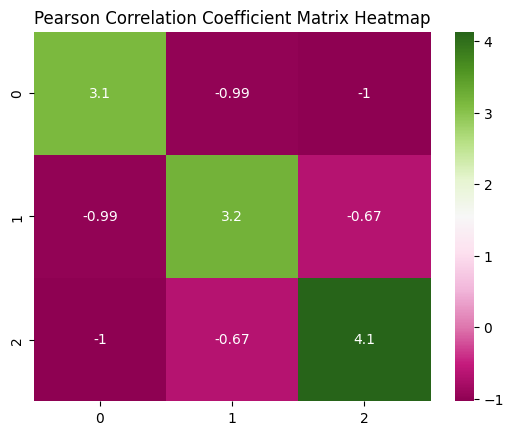

In [ ]:
# Pearson correlation coefficient
import numpy as np 
def pearson_correlation(data):

    covariance_matrix, data = compute_covariance_matrix(data)
    # print(covariance_matrix, data)
    pearson_corr = covariance_matrix / (np.prod(data.std()))
    pearson_corr_matrix = np.array(pearson_corr)
    print('Pearson Correlation Coefficient Matrix:\n', pearson_corr_matrix)
    return covariance_matrix, pearson_corr_matrix


data = {
   'A': np.random.rand(1000),
   'B': np.random.rand(1000),
   'C': np.random.rand(1000)
}
covariance_matrix, pearson_corr_matrix = pearson_correlation(data)

# Covariance matrix heatmap
sns.heatmap(covariance_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Pearson correlation coefficient heatmap
sns.heatmap(pearson_corr_matrix, annot=True, cmap='PiYG')
plt.title('Pearson Correlation Coefficient Matrix Heatmap')
plt.show()

In [99]:
## Why Box-Cox Transformation?
# Box-Cox transformation is used to 
# stabilize variance and make the data more normally distributed.


### Refrence 
- https://www.freecodecamp.org/news/normal-distribution-explained/
- https://www.analyticsvidhya.com/blog/2019/05/statistics-101-introduction-central-limit-theorem/
- https://www.statlect.com/fundamentals-of-probability/Chebyshev-inequality
- https://www.statisticshowto.com/probability-and-statistics/normal-distributions/box-cox-transformation/
- https://www.kaggle.com/code/utsavsarkar/statistical-analysis/notebook